In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#libraries for deeplearning 
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
#end 
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor#i need this since its lineair and curved
from sklearn.metrics import mean_squared_error
from sklearn.metrics import (
    confusion_matrix,           # The confusion matrix itself
    accuracy_score,              # Accuracy = (TP+TN)/(TP+TN+FP+FN)
    precision_score,             # Precision = TP/(TP+FP)
    recall_score,                # Recall = TP/(TP+FN)
    f1_score,                    # F1 = 2*(Precision*Recall)/(Precision+Recall)
    ConfusionMatrixDisplay,      # For visualizing confusion matrix
)
df=pd.read_csv("train.csv")
df

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,916,54,Female,VA Long Beach,asymptomatic,127.0,333.0,True,st-t abnormality,154.0,False,0.0,NaN,NaN,NaN,1
916,917,62,Male,VA Long Beach,typical angina,NaN,139.0,False,st-t abnormality,NaN,NaN,NaN,NaN,NaN,NaN,0
917,918,55,Male,VA Long Beach,asymptomatic,122.0,223.0,True,st-t abnormality,100.0,False,0.0,NaN,NaN,fixed defect,2
918,919,58,Male,VA Long Beach,asymptomatic,NaN,385.0,True,lv hypertrophy,NaN,NaN,NaN,NaN,NaN,NaN,0


In [129]:
#hundling missing values
df["trestbps"] = df["trestbps"].fillna(df["trestbps"].mean())
df["chol"] = df["chol"].fillna(df["chol"].mean())
df["fbs"] = df["fbs"].fillna(False)
df["restecg"] = df["restecg"].fillna("normal")
df["thalch"] = df["thalch"].fillna(df["thalch"].mean())
df["exang"] = df["exang"].fillna(False)
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].mean())
df["slope"] = df["slope"].fillna("flat")
df["ca"] = df["ca"].fillna(df["ca"].mean())
j=1
for i in range(0, len(df)):  # Use len(df) instead of hardcoded 920
    if pd.isna(df.iloc[i, 14]):  # Fixed: pd.isna() instead of np.isnan()
        if j < 244:
            df.iloc[i, 14] = "normal"
            j = j + 1
        else:
            df.iloc[i, 14] = "reversable defect"

In [130]:
#dropping unnacessary features
df.drop(["id"],axis=1,inplace=True)
df.drop(["dataset"],axis=1,inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.000000,233.0,True,lv hypertrophy,150.000000,False,2.300000,downsloping,0.000000,fixed defect,0
1,67,Male,asymptomatic,160.000000,286.0,False,lv hypertrophy,108.000000,True,1.500000,flat,3.000000,normal,2
2,67,Male,asymptomatic,120.000000,229.0,False,lv hypertrophy,129.000000,True,2.600000,flat,2.000000,reversable defect,1
3,37,Male,non-anginal,130.000000,250.0,False,normal,187.000000,False,3.500000,downsloping,0.000000,normal,0
4,41,Female,atypical angina,130.000000,204.0,False,lv hypertrophy,172.000000,False,1.400000,upsloping,0.000000,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,Female,asymptomatic,127.000000,333.0,True,st-t abnormality,154.000000,False,0.000000,flat,0.676375,reversable defect,1
916,62,Male,typical angina,132.132404,139.0,False,st-t abnormality,137.545665,False,0.878788,flat,0.676375,reversable defect,0
917,55,Male,asymptomatic,122.000000,223.0,True,st-t abnormality,100.000000,False,0.000000,flat,0.676375,fixed defect,2
918,58,Male,asymptomatic,132.132404,385.0,True,lv hypertrophy,137.545665,False,0.878788,flat,0.676375,reversable defect,0


In [131]:
df["sex"]=df["sex"].map({"Male":0 ,"Female":1})
df = pd.get_dummies(df, columns=["cp"], dtype=int)
df["fbs"]=df["fbs"].map({False:0,True:1})
df["exang"]=df["exang"].map({False:0,True:1})
df["restecg"] = df["restecg"].map( {"normal": 0, "st-t abnormality": 1, "lv hypertrophy": 2})
df = pd.get_dummies(df, columns=["slope"], dtype=int)
df["thal"] = df["thal"].map( {"normal": 0, "reversable defect": 1, "fixed defect": 2})


for i in range(0, len(df)):  
    if df.iloc[i, 11] !=0: 
       
      df.iloc[i, 11] = 1
            

df

,age,sex,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,ca,thal,num,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,slope_downsloping,slope_flat,slope_upsloping
0,63,0,145.000000,233.0,1,2,150.000000,0,2.300000,0.000000,2,0,0,0,0,1,1,0,0
1,67,0,160.000000,286.0,0,2,108.000000,1,1.500000,3.000000,0,1,1,0,0,0,0,1,0
2,67,0,120.000000,229.0,0,2,129.000000,1,2.600000,2.000000,1,1,1,0,0,0,0,1,0
3,37,0,130.000000,250.0,0,0,187.000000,0,3.500000,0.000000,0,0,0,0,1,0,1,0,0
4,41,1,130.000000,204.0,0,2,172.000000,0,1.400000,0.000000,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,1,127.000000,333.0,1,1,154.000000,0,0.000000,0.676375,1,1,1,0,0,0,0,1,0
916,62,0,132.132404,139.0,0,1,137.545665,0,0.878788,0.676375,1,0,0,0,0,1,0,1,0
917,55,0,122.000000,223.0,1,1,100.000000,0,0.000000,0.676375,2,1,1,0,0,0,0,1,0
918,58,0,132.132404,385.0,1,2,137.545665,0,0.878788,0.676375,1,0,1,0,0,0,0,1,0


In [132]:
y = df[["num"]]
df.drop(["num"],axis=1,inplace=True)

In [133]:
df1=df.copy()
df

,age,sex,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,ca,thal,cp_asymptomatic,cp_atypical angina,cp_non-anginal,cp_typical angina,slope_downsloping,slope_flat,slope_upsloping
0,63,0,145.000000,233.0,1,2,150.000000,0,2.300000,0.000000,2,0,0,0,1,1,0,0
1,67,0,160.000000,286.0,0,2,108.000000,1,1.500000,3.000000,0,1,0,0,0,0,1,0
2,67,0,120.000000,229.0,0,2,129.000000,1,2.600000,2.000000,1,1,0,0,0,0,1,0
3,37,0,130.000000,250.0,0,0,187.000000,0,3.500000,0.000000,0,0,0,1,0,1,0,0
4,41,1,130.000000,204.0,0,2,172.000000,0,1.400000,0.000000,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
915,54,1,127.000000,333.0,1,1,154.000000,0,0.000000,0.676375,1,1,0,0,0,0,1,0
916,62,0,132.132404,139.0,0,1,137.545665,0,0.878788,0.676375,1,0,0,0,1,0,1,0
917,55,0,122.000000,223.0,1,1,100.000000,0,0.000000,0.676375,2,1,0,0,0,0,1,0
918,58,0,132.132404,385.0,1,2,137.545665,0,0.878788,0.676375,1,1,0,0,0,0,1,0


In [134]:
#we scale the square footage columns, we use standardization 
df["age"]=StandardScaler().fit_transform(df[["age"]])
df["trestbps"]=StandardScaler().fit_transform(df[["trestbps"]])
df["chol"]=StandardScaler().fit_transform(df[["chol"]])
df["thalch"]=StandardScaler().fit_transform(df[["thalch"]])


df1["age"]=MinMaxScaler().fit_transform(df1[["age"]])
df1["trestbps"]=MinMaxScaler().fit_transform(df1[["trestbps"]])
df1["chol"]=MinMaxScaler().fit_transform(df1[["chol"]])
df1["thalch"]=MinMaxScaler().fit_transform(df1[["thalch"]])

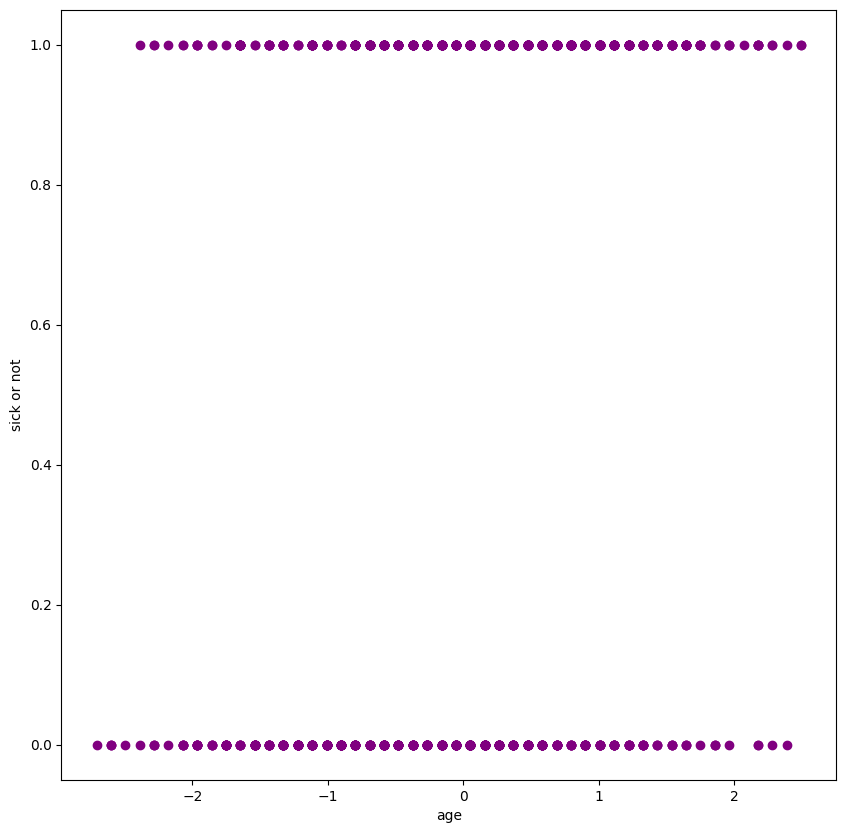

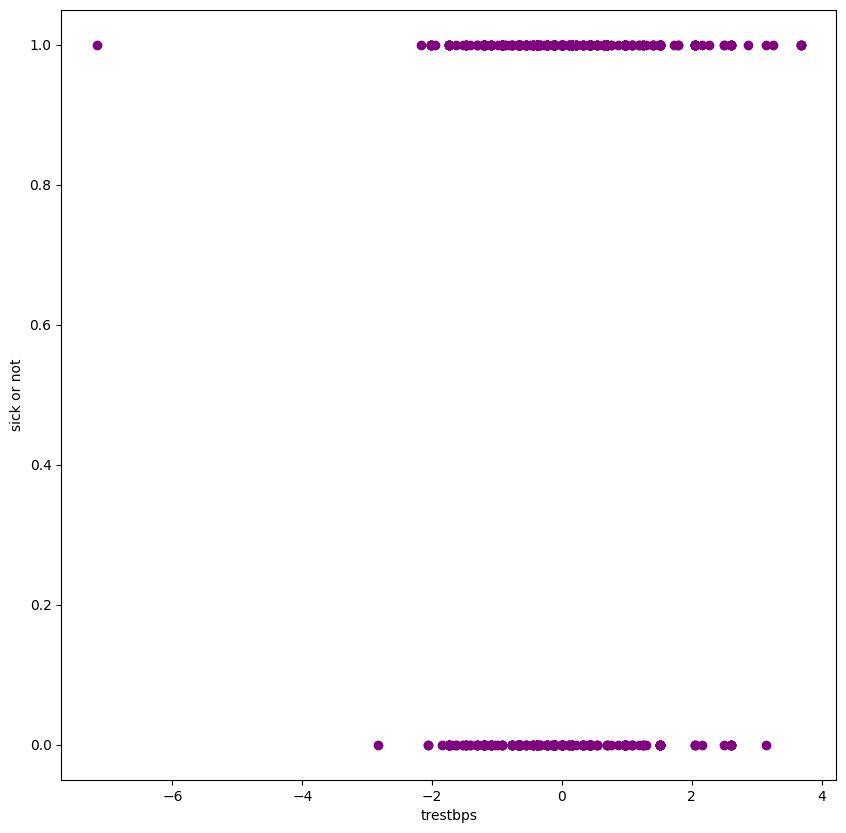

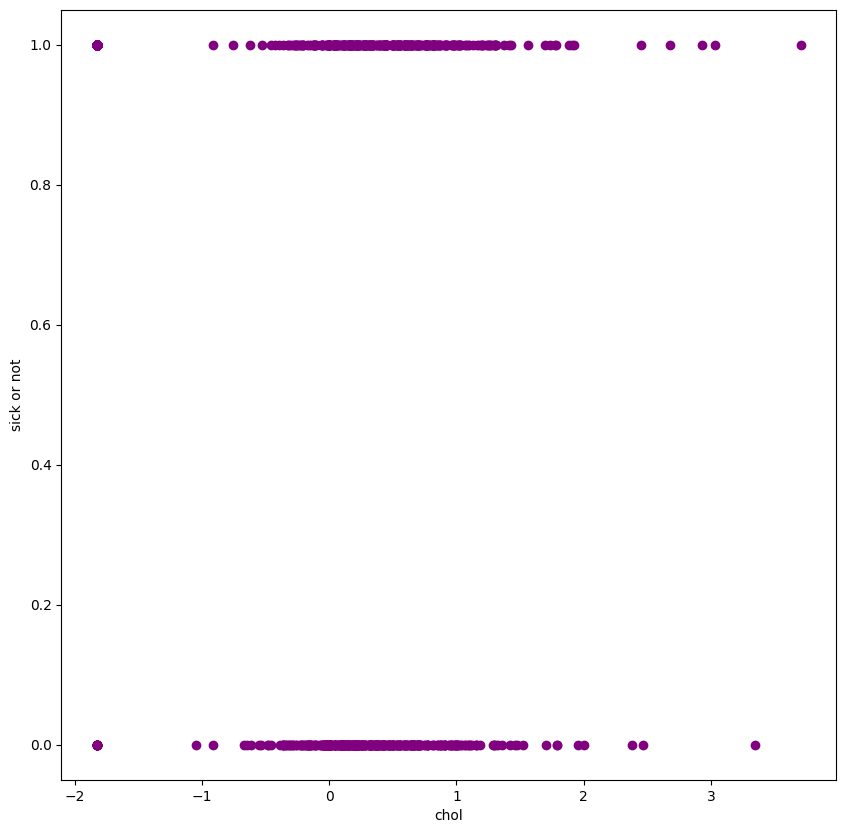

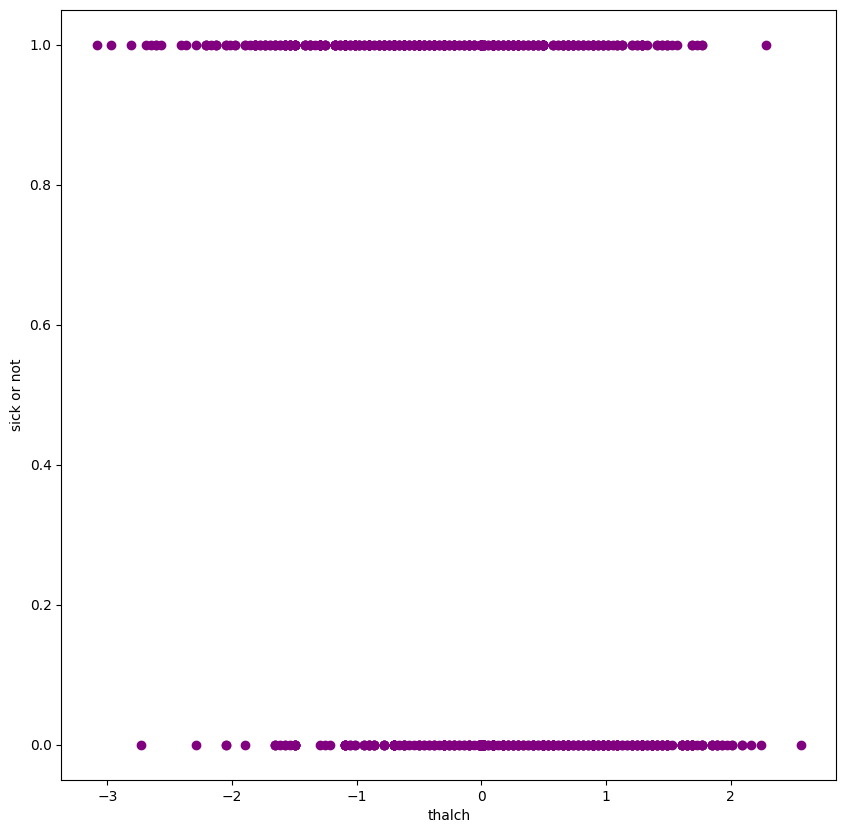

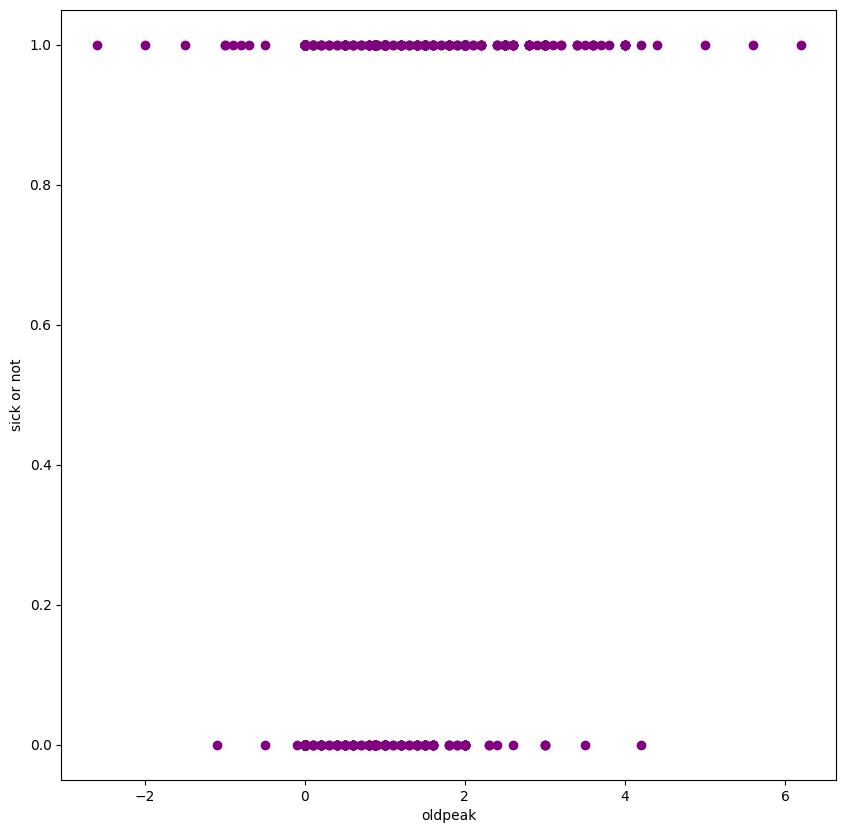

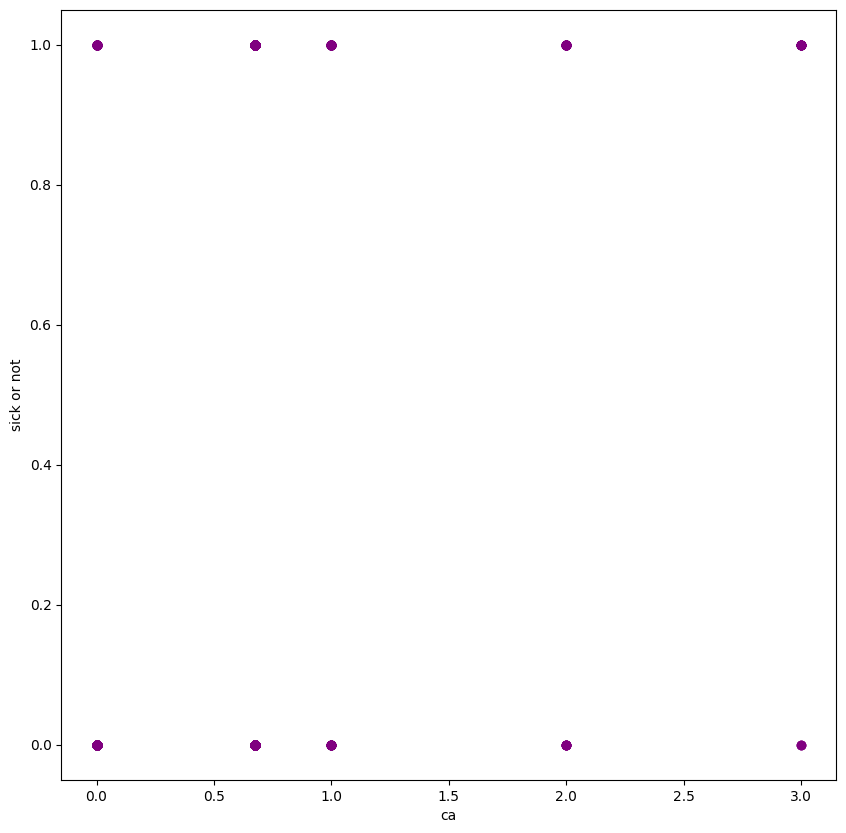

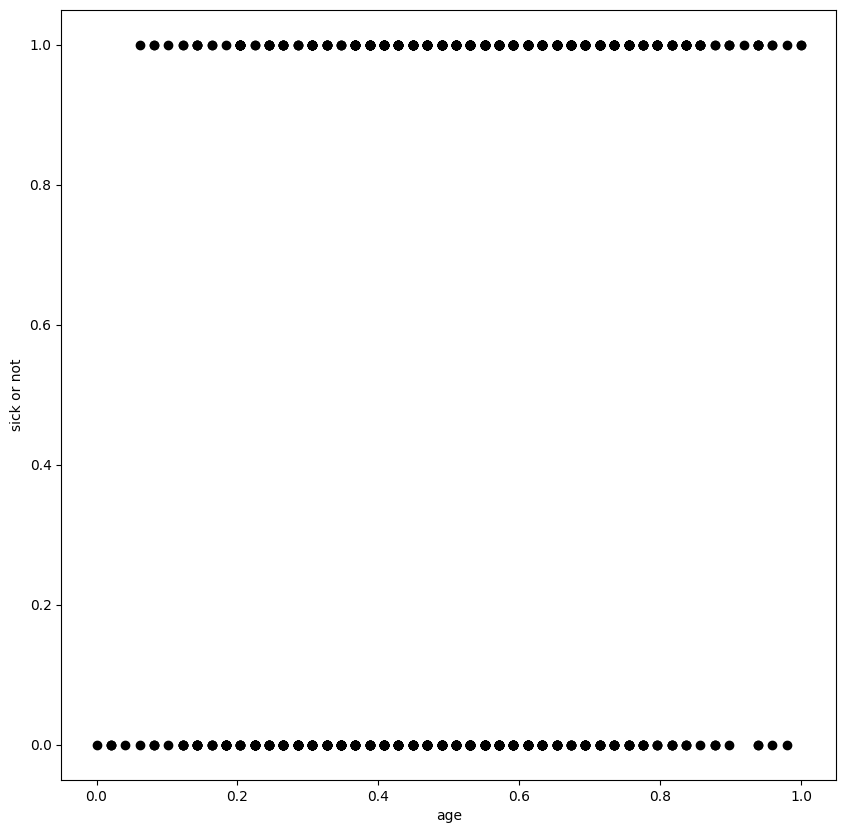

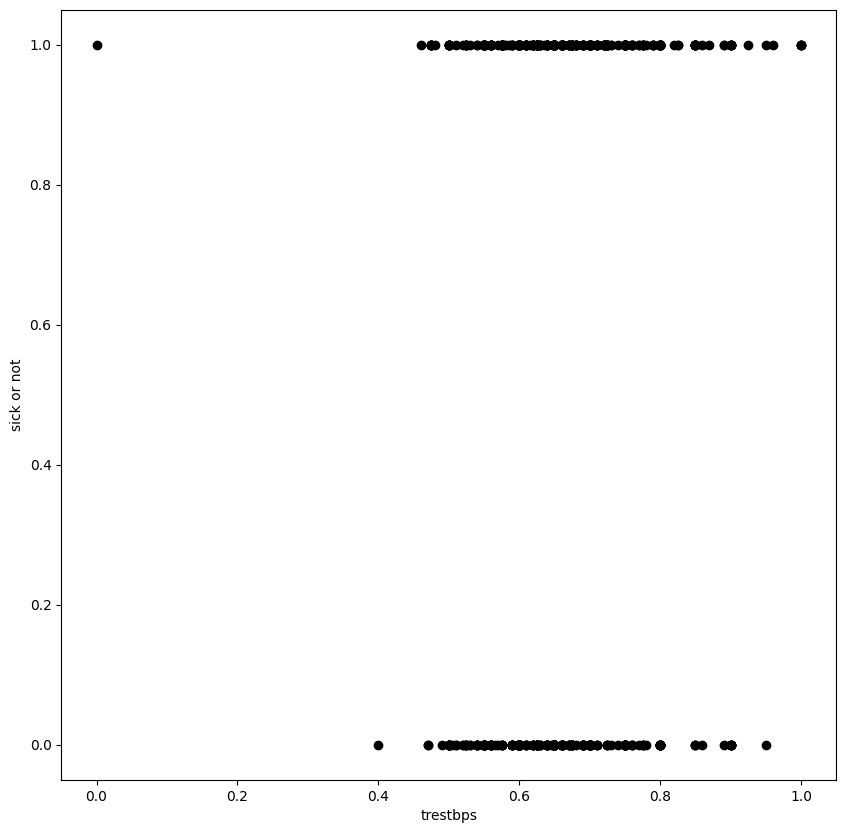

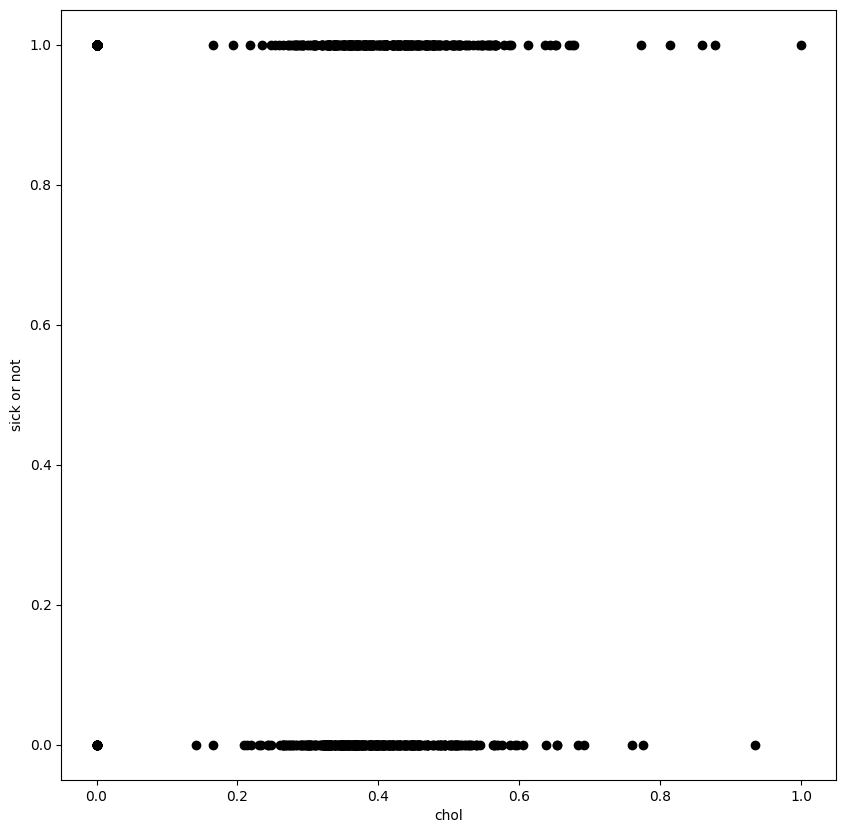

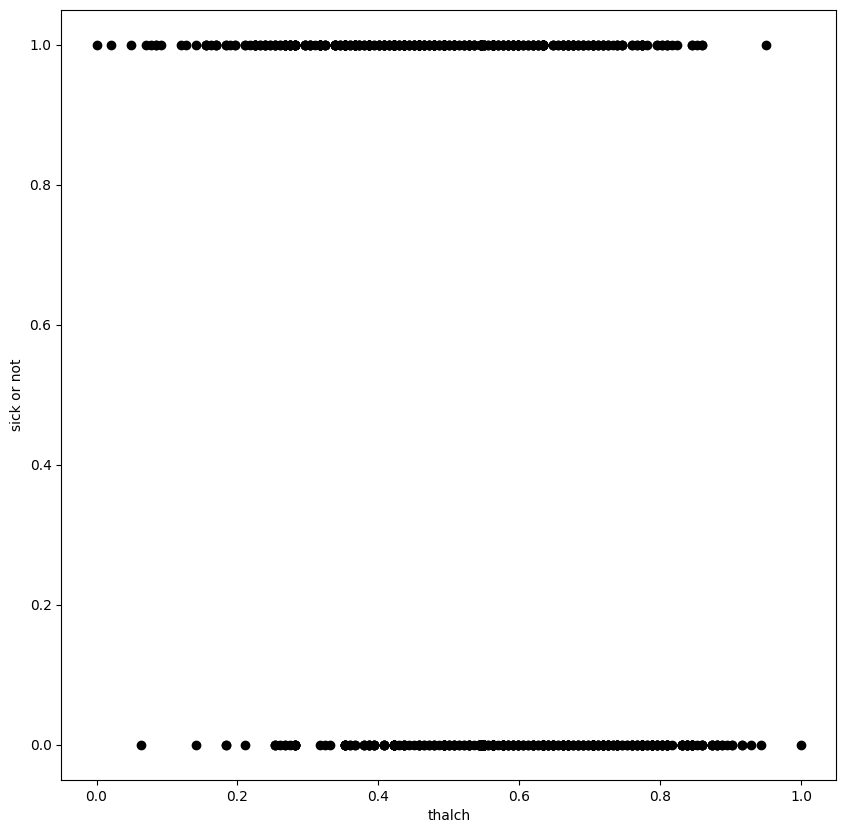

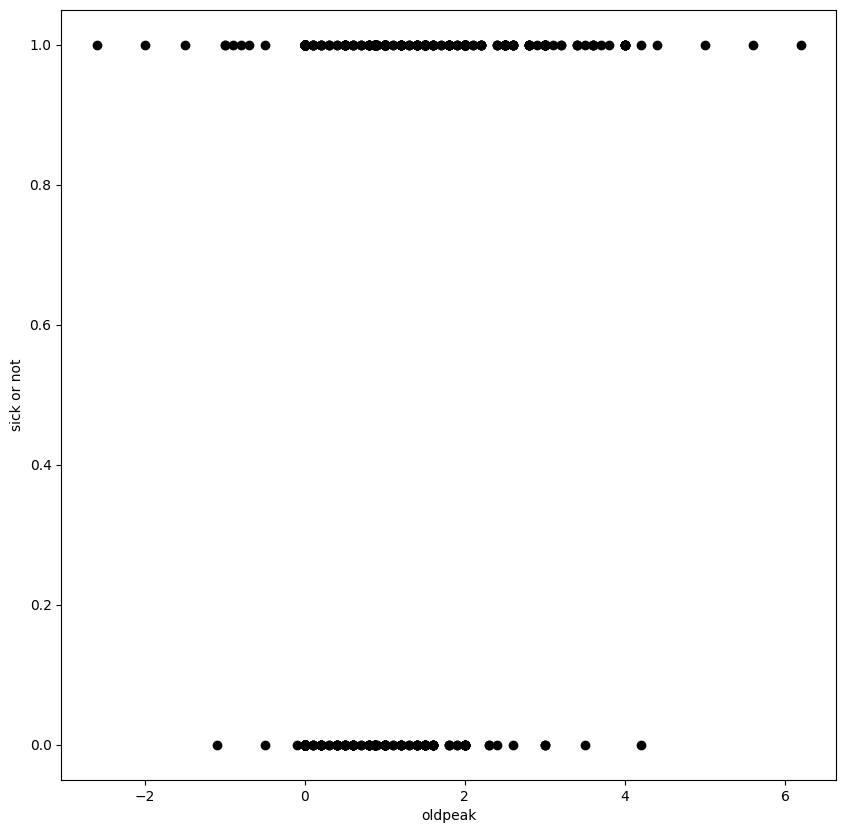

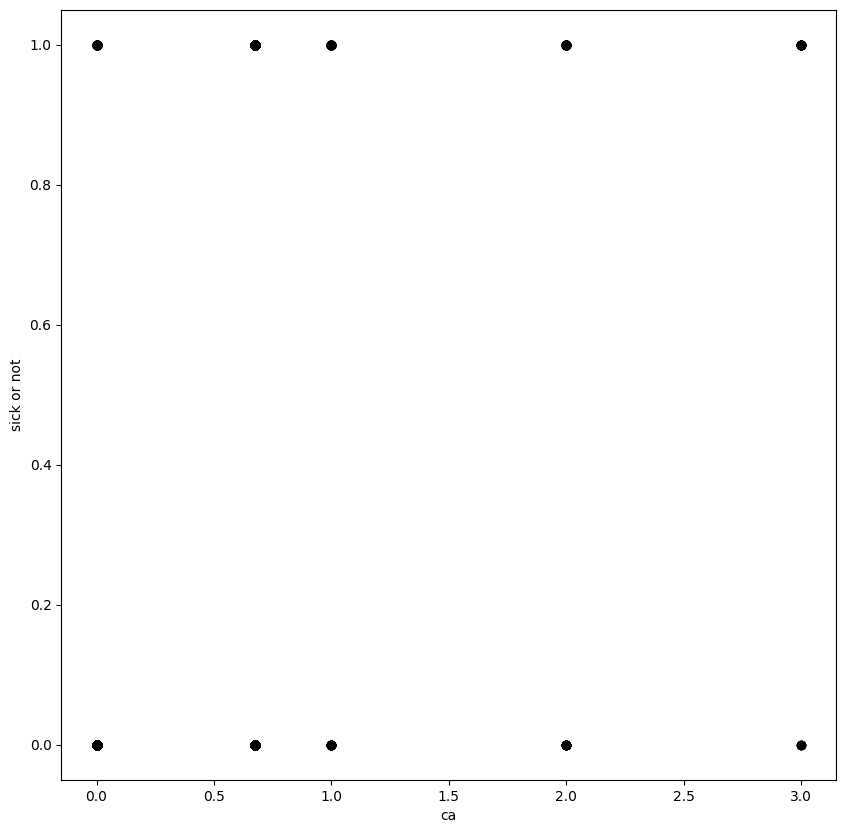

In [135]:
# viz

for i in ["age","trestbps","chol","thalch","oldpeak","ca"]:
    plt.figure(figsize=(10,10))
    plt.scatter(df[i],y,color="purple")
    plt.xlabel(i)
    plt.ylabel("sick or not")
    plt.show()



for i in ["age","trestbps","chol","thalch","oldpeak","ca"]:
    plt.figure(figsize=(10,10))
    plt.scatter(df1[i],y,color="black")
    plt.xlabel(i)
    plt.ylabel("sick or not")
    plt.show()

when visualizing , we see that we get pretty similar plots for both ML data  and DL data

In [136]:
y1=y.copy()

In [137]:
model = LogisticRegression()

x_train,x_test,y_train,y_test=train_test_split(
    df,y,test_size=0.10,random_state=42, stratify=y
)

smote = SMOTE(random_state=42, k_neighbors=5) 
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)
X_train_smote.info()

<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 916 non-null    float64
 1   sex                 916 non-null    int64  
 2   trestbps            916 non-null    float64
 3   chol                916 non-null    float64
 4   fbs                 916 non-null    int64  
 5   restecg             916 non-null    int64  
 6   thalch              916 non-null    float64
 7   exang               916 non-null    int64  
 8   oldpeak             916 non-null    float64
 9   ca                  916 non-null    float64
 10  thal                916 non-null    int64  
 11  cp_asymptomatic     916 non-null    int64  
 12  cp_atypical angina  916 non-null    int64  
 13  cp_non-anginal      916 non-null    int64  
 14  cp_typical angina   916 non-null    int64  
 15  slope_downsloping   916 non-null    int64  
 16  slope_flat         

In [138]:
model.fit(X_train_smote,y_train_smote)  

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [139]:

y_pred_proba = model.predict_proba(x_test)[:, 1]  

# Choosed a lower threshold (ex  0.2 instead of default 0.5)
threshold = 0.2
y_pred_custom = (y_pred_proba >= threshold).astype(int)

In [140]:
accuracy = accuracy_score(y_test,y_pred_custom)
precision = precision_score(y_test,y_pred_custom)
recall = recall_score(y_test,y_pred_custom)
f1 = f1_score(y_test,y_pred_custom)


print(f" Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f" Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f" Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f" F1-Score:  {f1:.4f} ({f1*100:.2f}%)")




 Accuracy:  0.8152 (81.52%)
 Precision: 0.7656 (76.56%)
 Recall:    0.9608 (96.08%)
 F1-Score:  0.8522 (85.22%)


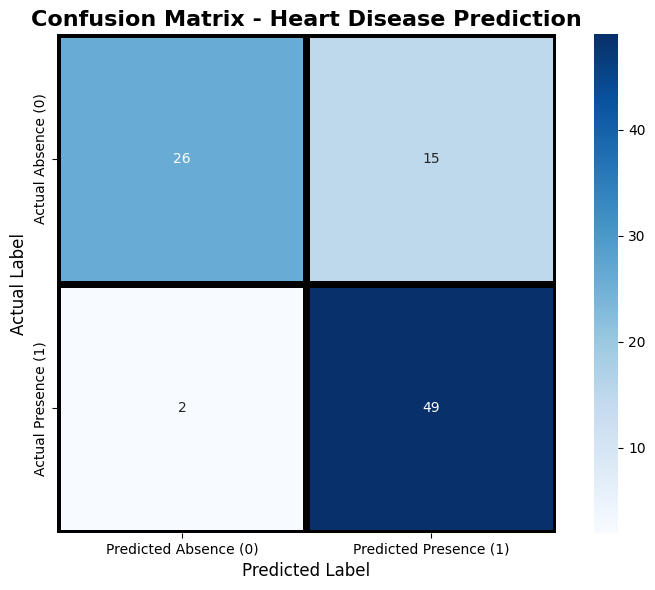

In [ ]:
cm = confusion_matrix(y_test,y_pred_custom)

# Create the visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,            # Show numbers in cells
            fmt='d',               # Integer format
            cmap='Blues',          # Color scheme
            cbar=True,             # Show color bar
            square=True,           # Square cells
            linewidths=5,          # Lines between cells
            linecolor='black',     # Line color
            
            xticklabels=['Predicted Absence (0)', 'Predicted Presence (1)'],
            yticklabels=['Actual Absence (0)', 'Actual Presence (1)'])""
plt.title('Confusion Matrix - Heart Disease Prediction', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()

we pass to the deep learning model

In [142]:
x_train1,x_test1,y_train1,y_test1=train_test_split(
    df1,y1,test_size=0.10,random_state=42
)


In [ ]:
models = keras.Sequential([
   
    layers.Dense(64, activation='relu', input_shape=(x_train1.shape[1],),
                 name='hidden_layer_1'),
    layers.Dense(32, activation='relu', name='hidden_layer_2'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [144]:
models.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy',"recall"]
     
)

In [ ]:
r=0
a=0
f=0
p=0
k=30
for i in range(30,101):
    
    history = models.fit(
      x_train1, y_train1,
      epochs=i,
      batch_size=32,
      validation_split=0.2,
      verbose=1
    )
    y_pred_proba = models.predict(x_test1).flatten()
    
    threshold = 0.2
    y_pred_custom = (y_pred_proba >= threshold).astype(int)
    accuracy = accuracy_score(y_test1,y_pred_custom)
    precision = precision_score(y_test1,y_pred_custom)
    recall = recall_score(y_test1,y_pred_custom)
    f1 = f1_score(y_test1,y_pred_custom)
    if (r<recall and a<accuracy):
        r=recall
        a=accuracy
        p=precision
        f=f1
        k=i
    
print(f" Accuracy:  {a:.4f} ")
print(f" Precision: {p:.4f} ")
print(f" Recall:    {r:.4f} ")
print(f" F1-Score:  {f:.4f} ")
print(f"the best epoch is {k}")
#k=30



Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6737 - loss: 0.6061 - recall: 0.8937 - val_accuracy: 0.7530 - val_loss: 0.5581 - val_recall: 0.9529
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7825 - loss: 0.5172 - recall: 0.9155 - val_accuracy: 0.8253 - val_loss: 0.4601 - val_recall: 0.9059
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8202 - loss: 0.4508 - recall: 0.8747 - val_accuracy: 0.8494 - val_loss: 0.4043 - val_recall: 0.9176
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8293 - loss: 0.4145 - recall: 0.8774 - val_accuracy: 0.8614 - val_loss: 0.3742 - val_recall: 0.9176
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8293 - loss: 0.3982 - recall: 0.8774 - val_accuracy: 0.8795 - val_loss: 0.3621 - val_recall: 0.9176
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8384 - loss: 0.3875 - recall: 0.8692 - val_accuracy: 0.8675 - val_loss: 0.3623 - val_recall: 0.9176
Epoch 7/30
21

In [150]:
print(a,p,r,f)

0.8260869565217391 0.8253968253968254 0.9122807017543859 0.8666666666666667


In [147]:
history = models.fit(
      x_train1, y_train1,
      epochs=30,
      batch_size=32,
      validation_split=0.2,
      verbose=1
    )
y_pred_proba = models.predict(x_test1).flatten()
    
threshold = 0.2
y_pred_custom = (y_pred_proba >= threshold).astype(int)

Epoch 1/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 9.0198e-04 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.6875 - val_recall: 0.8235
Epoch 2/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.9337e-04 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.6930 - val_recall: 0.8235
Epoch 3/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 9.2576e-04 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.7018 - val_recall: 0.8235
Epoch 4/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 9.6139e-04 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.7024 - val_recall: 0.8235
Epoch 5/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.9499e-04 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.7049 - val_recall: 0.8235
Epoch 6/30
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0010 - recall: 1.0000 - val_accuracy: 0.8012 - val_loss: 3.7202 - val_recall: 0.8

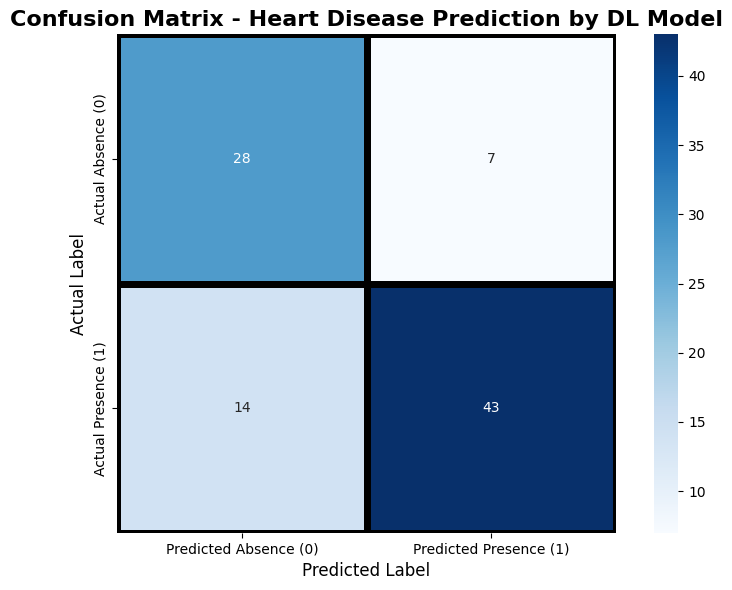

In [148]:
cm = confusion_matrix(y_test1,y_pred_custom)

# Create the visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, 
            annot=True,            # Show numbers in cells
            fmt='d',               # Integer format
            cmap='Blues',          # Color scheme
            cbar=True,             # Show color bar
            square=True,           # Square cells
            linewidths=5,          # Lines between cells
            linecolor='black',     # Line color
            
            xticklabels=['Predicted Absence (0)', 'Predicted Presence (1)'],
            yticklabels=['Actual Absence (0)', 'Actual Presence (1)'])
plt.title('Confusion Matrix - Heart Disease Prediction by DL Model', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.show()